In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
movies=pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\Telugu_Movies.csv")
movies.head()

,Sno,Movie,Year,Certificate,Genre,Runtime,Rating,No.of.Ratings
0,1224,Bhakta Prahlada,1932.0,U,"Drama, Fantasy",108,7.1,66
1,437,Pathala Bhairavi,1951.0,U,"Action, Adventure, Family",192,8.5,592
2,878,Malliswari,1951.0,U,"Drama, History, Musical",194,7.0,144
3,991,Kanchana,1952.0,U,Drama,165,7.0,106
4,732,Devadasu,1953.0,U,"Drama, Family, Musical",191,7.4,235


In [7]:
movies.info()
movies.describe()
movies.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sno            1400 non-null   int64  
 1   Movie          1400 non-null   object 
 2   Year           1352 non-null   float64
 3   Certificate    951 non-null    object 
 4   Genre          1389 non-null   object 
 5   Runtime        1400 non-null   int64  
 6   Rating         1400 non-null   float64
 7   No.of.Ratings  1400 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 87.6+ KB


Sno                0
Movie              0
Year              48
Certificate      449
Genre             11
Runtime            0
Rating             0
No.of.Ratings      0
dtype: int64

In [8]:
movies.rename(columns={
"Movie":"title",
"Year":"year",
"Certificate":"certificate",
"Genre":"genre",
"Runtime":"runtime",
"Rating":"rating",
"No.of.Ratings":"num_ratings"
}, inplace=True)

In [9]:
movies=movies.dropna()

In [10]:
movies=movies.drop_duplicates()

In [11]:
movies['runtime'] = pd.to_numeric(movies['runtime'], errors='coerce')

In [12]:
conn=sqlite3.connect("telugu_movies.db")

In [13]:
movies.to_sql("movies", conn, if_exists="replace", index=False)

915

In [24]:
query = """
SELECT title, rating
FROM movies
ORDER BY rating DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,title,rating
0,Pichhodu,9.5
1,Maya Bazaar,9.2
2,C/o Kancharapalem,9.0
3,Aha Naa Pellanta,8.9
4,Screenplay of an Indian Love Story,8.9
5,Gundamma Katha,8.8
6,Daana Veera Soora Karna,8.8
7,Sagara Sangamam,8.8
8,Runam,8.8
9,Sankarabharanam,8.7


In [25]:
query = """
SELECT title, num_ratings
FROM movies
ORDER BY num_ratings DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,title,num_ratings
0,Bahubali: The Beginning,99114
1,Baahubali 2: The Conclusion,71458
2,1 - Nenokkadine,42372
3,Dhoom:3,42112
4,Ra.One,37211
5,Dhoom:2,22983
6,Eega,20636
7,Krrish 3,20026
8,Arjun Reddy,19419
9,Rangasthalam,17559


In [26]:
query = """
SELECT year, COUNT(*) as total_movies
FROM movies
GROUP BY year
ORDER BY year
"""
pd.read_sql(query, conn)

,year,total_movies
0,1932.0,1
1,1951.0,2
2,1952.0,1
3,1953.0,1
4,1955.0,2
...,...,...
60,2016.0,49
61,2017.0,57
62,2018.0,68
63,2019.0,83


In [27]:
query = """
SELECT genre, COUNT(*) as total_movies
FROM movies
GROUP BY genre
ORDER BY total_movies DESC
"""
pd.read_sql(query, conn)

,genre,total_movies
0,"Action, Drama",100
1,Drama,70
2,"Action, Thriller",53
3,Action,51
4,"Drama, Romance",43
...,...,...
141,"Action, Biography, History",1
142,"Action, Adventure, Western",1
143,"Action, Adventure, Sci-Fi",1
144,"Action, Adventure, Romance",1


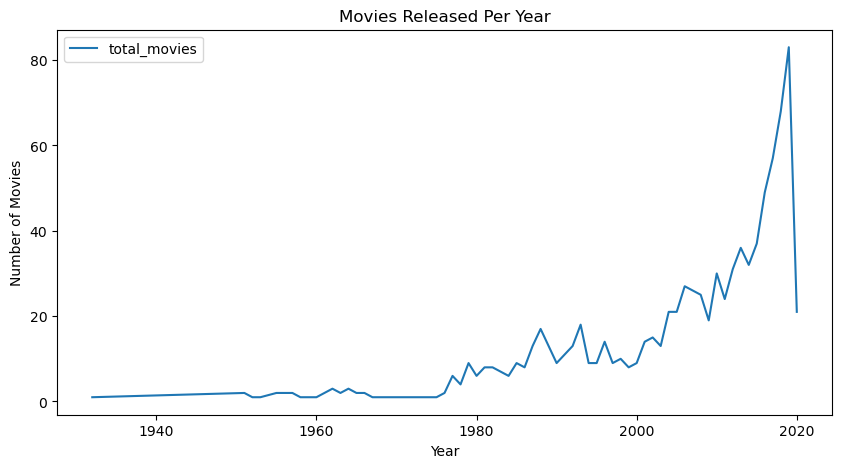

In [28]:
year_data = pd.read_sql("""
SELECT year, COUNT(*) as total_movies
FROM movies
GROUP BY year
""", conn)
year_data.plot(x="year", y="total_movies", kind="line", figsize=(10,5))
plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

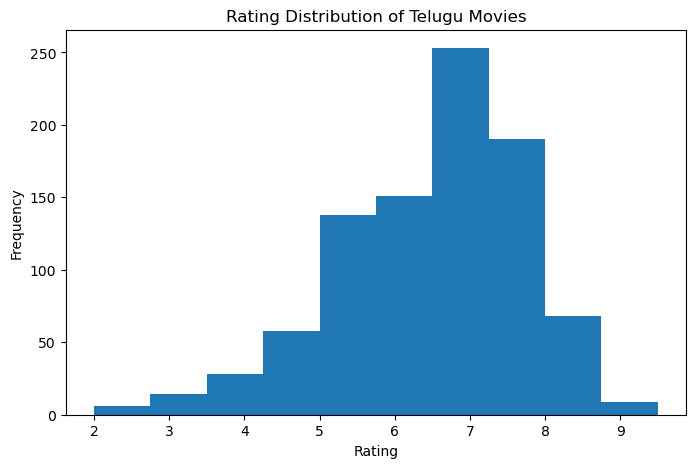

In [29]:
movies['rating'].plot(kind='hist', bins=10, figsize=(8,5))
plt.title("Rating Distribution of Telugu Movies")
plt.xlabel("Rating")
plt.show()

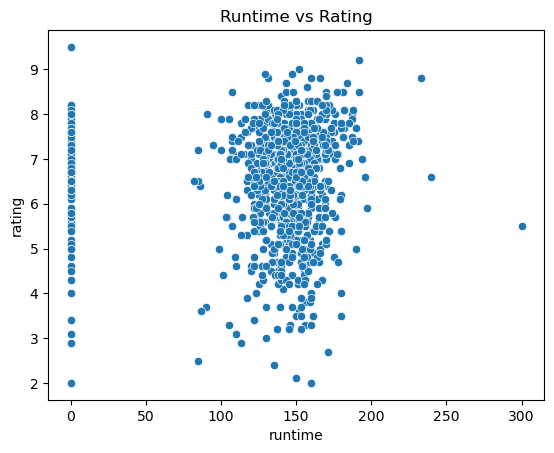

In [33]:
sns.scatterplot(x='runtime', y='rating', data=movies)
plt.title("Runtime vs Rating")
plt.show()

In [22]:
movies.to_csv("clean_telugu_movies.csv", index=False)